# Policy Lapse & Time-to-Premium Prediction

**Standalone notebook.** It generates its own data and defines every function it
uses. No project install, no local imports.
About 3 to 4 minutes top to bottom, 10 charts.

### The problem

At the moment a policy is pulled up, predict two things:

1. will this renewal premium **lapse**?
2. if not, **within how many days** will the premium arrive?

### The framing that makes it one problem

A lapse is not a separate event from a late payment. It is the *tail* of one
underlying quantity: **days from due date to premium receipt**. Lapse simply
means "that number exceeded the grace period."

So we model that one quantity over ordered time buckets:

| bucket | meaning |
|---|---|
| `d0_7`, `d8_15`, `d16_30`, `d31_grace` | paid inside the grace period |
| `lapsed` | no premium received inside grace |

`P(lapse)` is the last cell of the distribution; "how many days" is the shape of
the first four. One model, both answers, no stitching at inference, and no
stage-2 model that is blind to stage-1's mistakes.

### Before you run

**Dependencies**, all standard:

```bash
pip install pandas numpy scikit-learn lightgbm matplotlib jupyter
```

**Runtime**: about 3-4 minutes end to end on a laptop. The slowest step by far
is generating the synthetic book (a deliberate row-by-row loop, so the payment
history of each policy depends on its own past). If you want a faster pass,
change `n_policies=8000` to `3000` in the data cell. Every conclusion below
still holds, the numbers just get noisier.

**Nothing is written to disk** and nothing is read from it. The notebook creates
its own data in memory, so you can run it in any directory and delete nothing
afterwards.

### Contents

| # | Section | What you get |
|---|---|---|
| 1 | [Data](#s1) | a synthetic renewal ledger, one row per due date |
| 2 | [What the timing distribution looks like](#s2) | the bimodality that shapes every later choice |
| 3 | [Features and the leakage rule](#s3) | as-of-due-date features, plus a test that proves no look-ahead |
| 4 | [Target, maturity and the split](#s4) | the two traps that inflate offline scores |
| 5 | [Three ways to model it](#s5) | ordinal chain, multiclass, two-stage hurdle |
| 6 | [Evaluation](#s6) | PR-AUC, calibration, decile capture, expected days |
| 7 | [From probabilities to a call list](#s7) | the retention queue and its economics |
| 8 | [What to take away](#s8) | seven findings, and where the real gains are |

Every code cell opens with a header saying what it consumes and what it leaves
behind, so you can start reading at any section.

In [1]:
# ============================================================================
# 0.1  Imports and global settings
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : numpy/pandas/sklearn/lightgbm namespaces, SEED
# Note : SEED is fixed so every number in this notebook is reproducible.
# ============================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (average_precision_score, brier_score_loss,
                             log_loss, roc_auc_score)
from lightgbm import LGBMClassifier

pd.set_option("display.width", 150, "display.max_columns", 40)
SEED = 42
print("ready")

ready


## Chart styling

One validated categorical palette used throughout, so every chart in the
notebook reads as one system. The first three slots are colourblind-safe for
**all** pairs (worst-pair CVD ΔE 9.2), which is why no chart below uses more
than three colour-coded series. Three of the hues sit under 3:1 contrast on a
light surface, so every chart carries **direct labels** rather than relying on
colour alone.

In [2]:
# ============================================================================
# 0.2  Chart styling
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : BLUE/ORANGE/AQUA palette, style() and label_bars() helpers
# Note : One palette for the whole notebook, validated for colourblind
#        safety; three of its hues are low contrast, so charts carry direct
#        labels.
# ============================================================================
# Validated categorical slots (light mode). Assigned in fixed order, never cycled.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
SEQ = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#b8b7b2"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "600", "axes.titlelocation": "left",
    "axes.titlepad": 12, "axes.labelsize": 10,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "grid.color": "#e8e7e3", "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2, "lines.markersize": 8,
    "figure.dpi": 110, "font.size": 10,
})


def style(ax, title=None, sub=None, xlabel=None, ylabel=None, grid="y"):
    """Recessive grid, no chartjunk, subtitle carries the interpretation."""
    if title:
        ax.set_title(title, pad=22 if sub else 12)
    if sub:
        ax.text(0, 1.04, sub, transform=ax.transAxes, fontsize=9.5,
                color=INK2, va="bottom")
    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")
    if grid:
        ax.grid(axis=grid, alpha=0.9, zorder=0)
        ax.set_axisbelow(True)
    return ax


def label_bars(ax, bars, fmt="{:.1%}", pad=3, color=INK):
    """Direct labels -- required, since several palette slots are low-contrast."""
    for b in bars:
        h = b.get_height()
        ax.annotate(fmt.format(h), (b.get_x() + b.get_width() / 2, h),
                    textcoords="offset points", xytext=(0, pad),
                    ha="center", fontsize=9, color=color)


print("palette locked")

palette locked


---
<a id="s1"></a>
## 1. Data

A synthetic renewal ledger at the grain the model works at: **one row per
policy per premium due date**.

To use this notebook on real data, replace `generate_ledger()` with a query
returning the same columns. Everything downstream is unchanged. `days_to_pay`
is `NaN` when the premium was never received.

The generator deliberately builds in the structure that makes this problem
interesting: a latent per-policy *discipline* that payment history reveals,
lapses clustering in early policy years, an auto-debit effect, mild drift by
calendar year, and a **bimodal** payment-timing distribution (an on-time cluster
plus procrastinators who pay right at the grace deadline).

In [3]:
# ============================================================================
# 1.1  Generate the synthetic renewal ledger
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : ledger: one row per policy per premium due date
# Note : Replace generate_ledger() with a SQL pull of the same columns to
#        run this on a real book. Takes ~60s for 8,000 policies.
# ============================================================================
GRACE_DAYS = 45
BUCKETS = [("d0_7", 7), ("d8_15", 15), ("d16_30", 30), ("d31_grace", 45)]
CLASS_NAMES = [b[0] for b in BUCKETS] + ["lapsed"]
LAPSE_IDX = len(BUCKETS)
N_CLASSES = len(CLASS_NAMES)
EDGES = np.array([ub for _, ub in BUCKETS], dtype=float)

MODES = ["auto_debit", "manual_online", "manual_branch", "agent_collected"]
PRODUCTS = ["term", "endowment", "ulip", "money_back", "whole_life"]
CHANNELS = ["agency", "bancassurance", "direct", "broker"]
FREQS = {"yearly": 365, "half_yearly": 182, "quarterly": 91}


def generate_ledger(n_policies=8000, start="2019-01-01", end="2025-12-31", seed=SEED):
    rng = np.random.default_rng(seed)
    start, end = pd.Timestamp(start), pd.Timestamp(end)

    mode = rng.choice(MODES, n_policies, p=[0.34, 0.28, 0.18, 0.20])
    product = rng.choice(PRODUCTS, n_policies, p=[0.22, 0.28, 0.18, 0.17, 0.15])
    channel = rng.choice(CHANNELS, n_policies, p=[0.45, 0.25, 0.12, 0.18])
    freq = rng.choice(list(FREQS), n_policies, p=[0.6, 0.22, 0.18])
    annual_premium = np.round(rng.lognormal(9.9, 0.75, n_policies), -2)
    age = rng.integers(21, 66, n_policies)
    sa_mult = rng.choice([10, 15, 20, 25], n_policies)
    inception = start + pd.to_timedelta(
        rng.integers(-6 * 365, int((end - start).days * 0.6), n_policies), unit="D")
    agent_active = rng.random(n_policies) < 0.72

    # latent discipline -- what the model must infer from payment history
    discipline = rng.normal(0, 1, n_policies)
    discipline += np.where(mode == "auto_debit", 1.1, 0.0)
    discipline += np.where(channel == "direct", 0.25, 0.0)
    discipline -= np.where(product == "ulip", 0.35, 0.0)
    discipline -= 0.20 * (np.log(annual_premium) - np.log(annual_premium).mean())

    rows = []
    for i in range(n_policies):
        step = FREQS[freq[i]]
        due = inception[i] + pd.Timedelta(days=step)
        pol_year, prior_lapses, hist = 1, 0, []
        while due <= end:
            year_pen = {1: 0.55, 2: 0.35, 3: 0.20}.get(pol_year, 0.0)
            drift = 0.12 * (due.year - 2019) / 6.0
            z = (discipline[i] - year_pen - drift
                 - 0.30 * min(prior_lapses, 3)
                 - (0.0 if agent_active[i] else 0.25)
                 + 0.20 * (np.mean(hist[-3:]) < 5 if hist else 0))
            if rng.random() < 1 / (1 + np.exp(-(3.10 + 1.05 * z))):
                # bimodal: on-time cluster, or a push right up to the deadline
                if rng.random() < 1 / (1 + np.exp(-(0.6 + z))):
                    d = min(GRACE_DAYS, rng.gamma(1.4, 3.0))
                else:
                    d = min(GRACE_DAYS, GRACE_DAYS - abs(rng.normal(0, 8)))
                days_to_pay = float(round(d))
            else:
                days_to_pay = (float(GRACE_DAYS + rng.integers(5, 320))
                               if rng.random() < 0.28 else np.nan)  # revival tail
                prior_lapses += 1
            rows.append((f"P{i:07d}", due, pol_year, freq[i], mode[i], product[i],
                         channel[i], float(annual_premium[i]), int(age[i]),
                         int(sa_mult[i]), bool(agent_active[i]), days_to_pay))
            hist.append(min(days_to_pay, GRACE_DAYS)
                        if days_to_pay == days_to_pay else GRACE_DAYS)
            due += pd.Timedelta(days=step)
            pol_year = int((due - inception[i]).days // 365) + 1

    return pd.DataFrame(rows, columns=[
        "policy_id", "due_date", "policy_year", "premium_freq", "payment_mode",
        "product", "channel", "annual_premium", "cust_age", "sum_assured_mult",
        "agent_active", "days_to_pay"]).sort_values(
        ["policy_id", "due_date"], ignore_index=True)


ledger = generate_ledger()
print(f"{len(ledger):,} due events | {ledger.policy_id.nunique():,} policies | "
      f"{ledger.due_date.min().date()} -> {ledger.due_date.max().date()}")
ledger.head()

106,784 due events | 8,000 policies | 2013-04-17 -> 2025-12-31


,policy_id,due_date,policy_year,premium_freq,payment_mode,product,channel,annual_premium,cust_age,sum_assured_mult,agent_active,days_to_pay
0,P0000000,2020-07-06,1,half_yearly,manual_branch,ulip,bancassurance,27000.0,33,10,True,NaN
1,P0000000,2021-01-04,1,half_yearly,manual_branch,ulip,bancassurance,27000.0,33,10,True,44.0
2,P0000000,2021-07-05,2,half_yearly,manual_branch,ulip,bancassurance,27000.0,33,10,True,30.0
3,P0000000,2022-01-03,2,half_yearly,manual_branch,ulip,bancassurance,27000.0,33,10,True,3.0
4,P0000000,2022-07-04,3,half_yearly,manual_branch,ulip,bancassurance,27000.0,33,10,True,NaN


---
<a id="s2"></a>
## 2. What the payment-timing distribution looks like

This chart is the whole argument for the modelling approach, so it comes first.

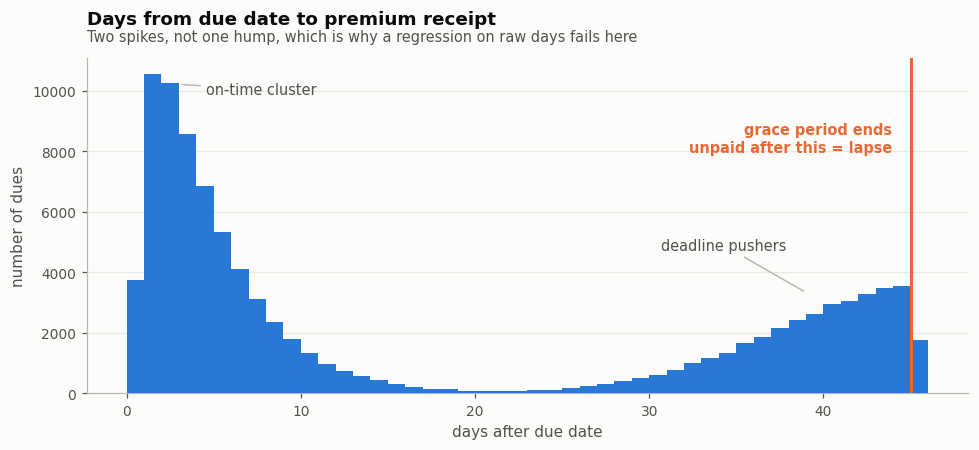

median 7 days | share paid within 7 days 54.0% | share in the last week of grace 21.2%


In [4]:
# ============================================================================
# 2.1  Days-to-payment distribution
# ----------------------------------------------------------------------------
# In   : ledger
# Out  : histogram of days-to-pay inside the grace window
# Note : The bimodality here is the argument for bucketing rather than
#        regressing on raw days.
# ============================================================================
paid = ledger["days_to_pay"].dropna()
in_grace = paid[paid <= GRACE_DAYS]

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(in_grace, bins=np.arange(0, GRACE_DAYS + 2), color=BLUE, zorder=3)
ax.axvline(GRACE_DAYS, color=ORANGE, lw=2, zorder=4)
ax.annotate("grace period ends\nunpaid after this = lapse", (GRACE_DAYS, ax.get_ylim()[1] * 0.72),
            xytext=(-12, 0), textcoords="offset points", ha="right",
            fontsize=9.5, color=ORANGE, weight="600")
ax.annotate("on-time cluster", (3, ax.get_ylim()[1] * 0.92), xytext=(18, -6),
            textcoords="offset points", fontsize=9.5, color=INK2,
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=1))
ax.annotate("deadline pushers", (39, ax.get_ylim()[1] * 0.30), xytext=(-95, 28),
            textcoords="offset points", fontsize=9.5, color=INK2,
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=1))
style(ax, "Days from due date to premium receipt",
      "Two spikes, not one hump, which is why a regression on raw days fails here",
      "days after due date", "number of dues")
plt.tight_layout(); plt.show()

print(f"median {paid.median():.0f} days | share paid within 7 days "
      f"{(in_grace <= 7).mean():.1%} | share in the last week of grace "
      f"{((in_grace > 38) & (in_grace <= 45)).mean():.1%}")

**This chart drives every later decision.**

The distribution is *bimodal and spiky*: a large mass in the first few days, then
a second pile-up right against the grace deadline. It has no meaningful central
tendency.

Two consequences:

- **Never regress on raw days.** A model minimising MAE will predict the empty
  middle, which is the one answer that is almost never right. Predict *buckets*
  and derive expected days from the distribution instead.
- **The mass just inside the deadline is where the money is.** Those policies
  are one nudge away from lapsing, and they are the retention team's real target,
  not the on-time payers and not the already-lost.

### Who lapses

Three cuts, each a single-series chart with direct labels.

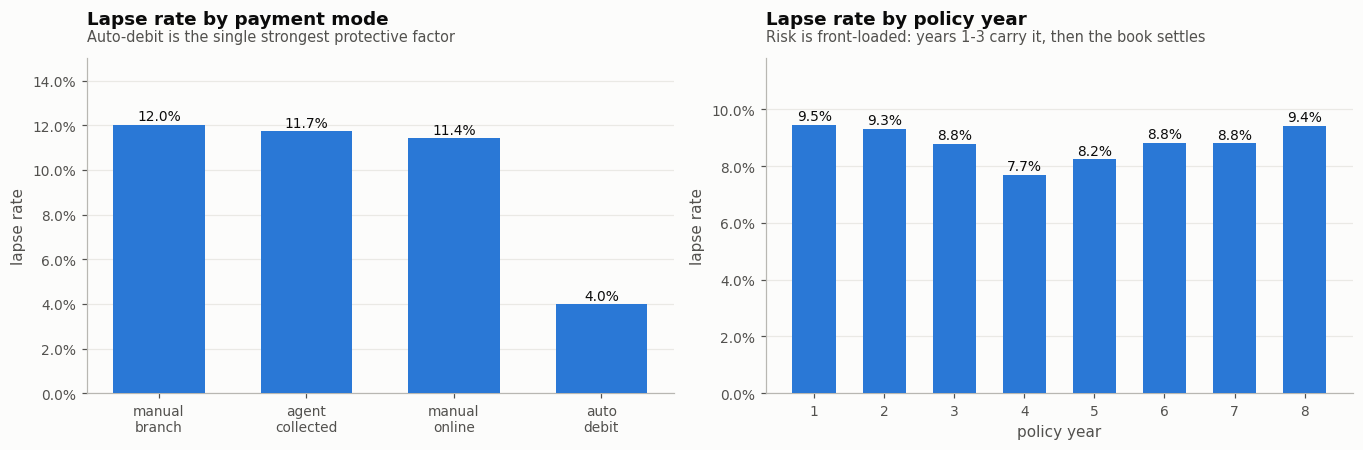

In [5]:
# ============================================================================
# 2.2  Lapse rate by payment mode and policy year
# ----------------------------------------------------------------------------
# In   : ledger
# Out  : lapse_rate_by() helper, two bar charts
# Note : min_n guards against reading a rate off a handful of rows.
# ============================================================================
def lapse_rate_by(df, col, min_n=200):
    g = df.assign(_l=df["days_to_pay"].isna() | (df["days_to_pay"] > GRACE_DAYS))
    out = g.groupby(col)["_l"].agg(["mean", "size"])
    return out[out["size"] >= min_n].sort_values("mean", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

m = lapse_rate_by(ledger, "payment_mode")
bars = axes[0].bar(range(len(m)), m["mean"], color=BLUE, zorder=3, width=0.62)
axes[0].set_xticks(range(len(m)), [i.replace("_", "\n") for i in m.index])
label_bars(axes[0], bars)
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_ylim(0, m["mean"].max() * 1.25)
style(axes[0], "Lapse rate by payment mode",
      "Auto-debit is the single strongest protective factor", ylabel="lapse rate")

y = lapse_rate_by(ledger, "policy_year").sort_index()
y = y[y.index <= 8]
bars = axes[1].bar(y.index, y["mean"], color=BLUE, zorder=3, width=0.62)
label_bars(axes[1], bars)
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_ylim(0, y["mean"].max() * 1.25)
style(axes[1], "Lapse rate by policy year",
      "Risk is front-loaded: years 1-3 carry it, then the book settles",
      "policy year", "lapse rate")
plt.tight_layout(); plt.show()

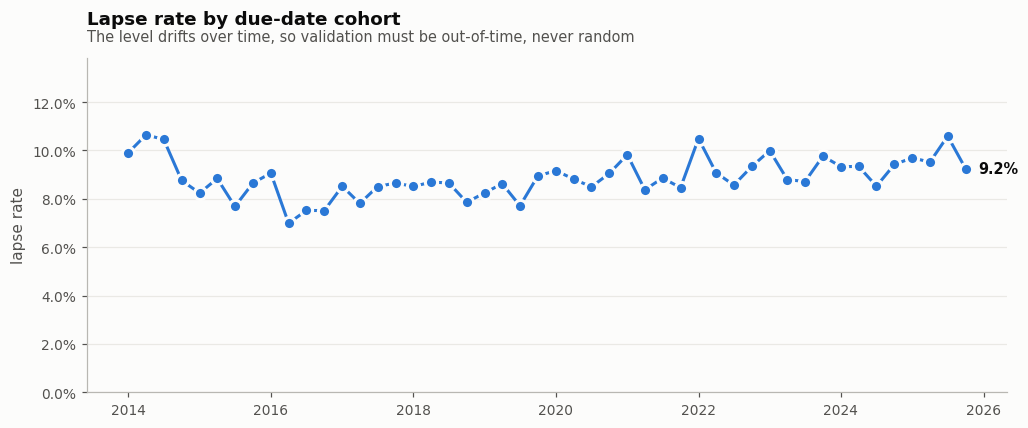

In [6]:
# ============================================================================
# 2.3  Lapse rate by due-date cohort
# ----------------------------------------------------------------------------
# In   : ledger
# Out  : time series of lapse rate by quarter
# Note : The drift visible here is why validation must be out-of-time.
# ============================================================================
q = (ledger.assign(_l=ledger["days_to_pay"].isna() | (ledger["days_to_pay"] > GRACE_DAYS),
                   quarter=ledger["due_date"].dt.to_period("Q").dt.to_timestamp())
     .groupby("quarter")["_l"].agg(["mean", "size"]))
q = q[q["size"] >= 300]

fig, ax = plt.subplots(figsize=(9.5, 4))
ax.plot(q.index, q["mean"], color=BLUE, marker="o", zorder=3,
        markerfacecolor=BLUE, markeredgecolor=SURFACE, markeredgewidth=2)
ax.annotate(f"{q['mean'].iloc[-1]:.1%}", (q.index[-1], q["mean"].iloc[-1]),
            xytext=(8, 0), textcoords="offset points", fontsize=9.5,
            color=INK, weight="600", va="center")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylim(0, q["mean"].max() * 1.3)
style(ax, "Lapse rate by due-date cohort",
      "The level drifts over time, so validation must be out-of-time, never random",
      ylabel="lapse rate")
plt.tight_layout(); plt.show()

The drift in that last chart is the reason for a rule that gets broken constantly:
**split by due-date cohort, never randomly.** A random split lets the model learn
from the future and reports a score you will never reproduce in production.

---
<a id="s3"></a>
## 3. Features, and the leakage rule

**Every feature must be knowable at the due date.** Reminder calls, collection
actions and payment confirmations that happen *after* it cannot be inputs, or the
model learns the answer and collapses the moment it goes live.

The rule is enforced structurally rather than by care: all history features are
built with `groupby.shift(1)`, strictly prior dues, and the target columns are
blacklisted out of the feature matrix.

In [7]:
# ============================================================================
# 3.1  Build the as-of-due-date feature matrix
# ----------------------------------------------------------------------------
# In   : ledger
# Out  : feat (features), FEATURES (column list)
# Note : Every history feature uses groupby.shift(1), so the current due's
#        outcome cannot reach its own row.
# ============================================================================
CATEGORICAL = ["premium_freq", "payment_mode", "product", "channel"]
LEAKY = {"days_to_pay", "bucket", "lapsed"}


def build_features(df):
    df = df.sort_values(["policy_id", "due_date"]).copy()
    g = df.groupby("policy_id", sort=False)

    capped = df["days_to_pay"].clip(upper=GRACE_DAYS).fillna(GRACE_DAYS)
    was_lapse = (df["days_to_pay"].isna() | (df["days_to_pay"] > GRACE_DAYS)).astype(int)
    df["_capped"], df["_lapse"] = capped, was_lapse

    # --- history: shift(1) FIRST, so the current due can never contribute ---
    prev = g["_capped"].shift(1)
    for k in (1, 2, 3):
        df[f"days_late_lag{k}"] = g["_capped"].shift(k)
    roll = g["_capped"].shift(1).groupby(df["policy_id"])
    df["days_late_mean3"] = roll.rolling(3, min_periods=1).mean().reset_index(level=0, drop=True)
    df["days_late_max3"] = roll.rolling(3, min_periods=1).max().reset_index(level=0, drop=True)
    df["days_late_std3"] = roll.rolling(3, min_periods=2).std().reset_index(level=0, drop=True)
    df["days_late_trend"] = prev - df["days_late_lag2"]

    df["prior_dues"] = g.cumcount()
    df["prior_lapses"] = g["_lapse"].shift(1).groupby(df["policy_id"]).cumsum().fillna(0)
    df["prior_lapse_rate"] = df["prior_lapses"] / df["prior_dues"].replace(0, np.nan)
    df["ontime_rate"] = (g["_capped"].shift(1).le(7).groupby(df["policy_id"])
                         .expanding().mean().reset_index(level=0, drop=True))
    df["ever_lapsed"] = (df["prior_lapses"] > 0).astype(int)

    # --- exposure, seasonality, money ---
    df["due_month"] = df["due_date"].dt.month
    df["due_quarter"] = df["due_date"].dt.quarter
    df["is_first_renewal"] = (df["prior_dues"] == 0).astype(int)
    df["log_premium"] = np.log1p(df["annual_premium"])
    df["premium_per_year_of_age"] = df["annual_premium"] / df["cust_age"]
    df["sum_assured"] = df["annual_premium"] * df["sum_assured_mult"]
    df["agent_active"] = df["agent_active"].astype(int)

    for c in CATEGORICAL:
        df[c] = df[c].astype("category")
    return df.drop(columns=["_capped", "_lapse"])


def feature_columns(df):
    return [c for c in df.columns if c not in (LEAKY | {"policy_id", "due_date"})]


feat = build_features(ledger)
FEATURES = feature_columns(feat)
assert not LEAKY.intersection(FEATURES), "a target column reached the feature matrix"
print(f"{len(FEATURES)} features")

27 features


### Proving there is no look-ahead

A column blacklist only catches leakage you thought of. This is the check that
catches the rest: **change the current due's outcome to something absurd and
confirm not one feature on that row moves.** If any feature were built from the
current payment, it would move.

In [8]:
# ============================================================================
# 3.2  Prove there is no look-ahead leakage
# ----------------------------------------------------------------------------
# In   : ledger, build_features()
# Out  : PASS/FAIL assertion
# Note : Changes one due's outcome to an absurd value and asserts no feature
#        on that row moves. Catches leaks a column blacklist would miss.
# ============================================================================
pid = ledger["policy_id"].value_counts().idxmax()
pol = ledger[ledger.policy_id == pid].sort_values("due_date")

before = build_features(pol.copy()).iloc[-1][FEATURES]
tampered = pol.copy()
tampered.loc[tampered.index[-1], "days_to_pay"] = 999.0   # absurd outcome
after = build_features(tampered).iloc[-1][FEATURES]

moved = [c for c in FEATURES if not (pd.isna(before[c]) and pd.isna(after[c]))
         and not (before[c] == after[c])]
print(f"features that moved when the current outcome changed: {moved}")
assert not moved, "LEAKAGE: a feature depends on the current due's payment"
print("PASS - every feature is knowable as of the due date")

features that moved when the current outcome changed: []
PASS - every feature is knowable as of the due date


---
<a id="s4"></a>
## 4. Target, cohort maturity, and the out-of-time split

Two traps live here, and both inflate offline scores silently.

**Trap 1, immature cohorts.** A due from last week has not lapsed; it simply
has not resolved yet. Training on it labels "not yet paid" as "lapsed" and
teaches the model nonsense. Only cohorts whose grace period has *fully elapsed*
are eligible.

**Trap 2, random splits.** Lapse behaviour drifts (see the cohort chart above),
so validation must be a *later* period than training, never a random sample of
the same one.

In [9]:
# ============================================================================
# 4.1  Target, cohort maturity and the out-of-time split
# ----------------------------------------------------------------------------
# In   : feat
# Out  : data (mature rows), train / test / valid
# Note : mature() drops dues whose grace period has not elapsed; training on
#        them would relabel not-yet-paid as lapsed.
# ============================================================================
def bucket_of(d):
    if d is None or d != d or d > GRACE_DAYS:
        return LAPSE_IDX
    for i, (_, ub) in enumerate(BUCKETS):
        if d <= ub:
            return i
    return LAPSE_IDX


def add_labels(df):
    df = df.copy()
    df["bucket"] = df["days_to_pay"].map(bucket_of).astype(int)
    df["lapsed"] = (df["bucket"] == LAPSE_IDX).astype(int)
    return df


def mature(df, as_of=None):
    as_of = pd.Timestamp(as_of) if as_of is not None else df["due_date"].max()
    return df[df["due_date"] + pd.Timedelta(days=GRACE_DAYS) <= as_of].copy()


def time_split(df, valid_months=3, test_months=3):
    end = df["due_date"].max()
    v0 = end - pd.DateOffset(months=valid_months)
    t0 = v0 - pd.DateOffset(months=test_months)
    return (df[df.due_date < t0].copy(),
            df[(df.due_date >= t0) & (df.due_date < v0)].copy(),
            df[df.due_date >= v0].copy())


data = mature(add_labels(feat))
print(f"dropped {len(feat) - len(data):,} immature dues "
      f"({(1 - len(data)/len(feat)):.1%} of the book)")

train, test, valid = time_split(data)
for nm, d in [("train", train), ("test (OOT)", test), ("valid (recent)", valid)]:
    print(f"{nm:16s} {len(d):>8,}   {d.due_date.min().date()} -> "
          f"{d.due_date.max().date()}   lapse={d.lapsed.mean():.3f}")
assert train.due_date.max() < test.due_date.min() < valid.due_date.min()

dropped 1,752 immature dues (1.6% of the book)
train              97,942   2013-04-17 -> 2025-05-15   lapse=0.089
test (OOT)          3,586   2025-05-16 -> 2025-08-15   lapse=0.097
valid (recent)      3,504   2025-08-16 -> 2025-11-16   lapse=0.100


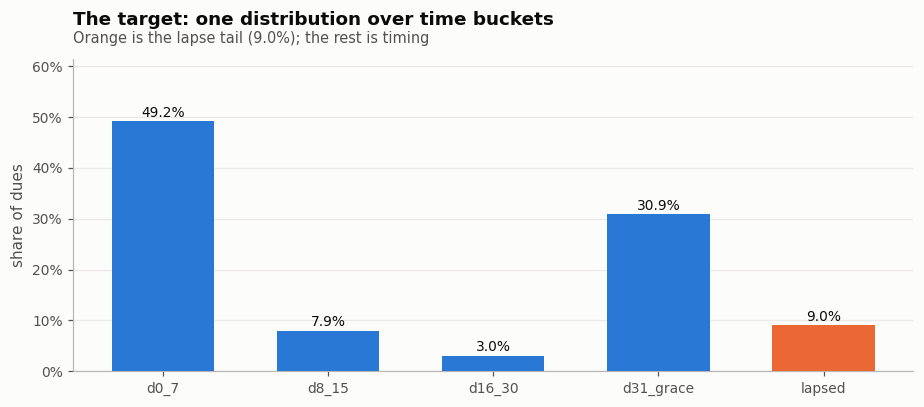

In [10]:
# ============================================================================
# 4.2  Bucket mix of the target
# ----------------------------------------------------------------------------
# In   : data
# Out  : bar chart of the five-bucket distribution
# Note : Most premiums arrive in the first week. The lapse bucket is the
#        small tail on the right, and that imbalance is why PR-AUC beats AUC
#        here.
# ============================================================================
mix = data["bucket"].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(8.5, 3.8))
colors = [BLUE] * LAPSE_IDX + [ORANGE]
bars = ax.bar(range(N_CLASSES), mix.values, color=colors, zorder=3, width=0.62)
label_bars(ax, bars)
ax.set_xticks(range(N_CLASSES), CLASS_NAMES)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylim(0, mix.max() * 1.25)
style(ax, "The target: one distribution over time buckets",
      f"Orange is the lapse tail ({mix.iloc[LAPSE_IDX]:.1%}); the rest is timing",
      ylabel="share of dues")
plt.tight_layout(); plt.show()

---
<a id="s5"></a>
## 5. Three ways to model it

All three produce the **same output shape**, a probability for each of the five
buckets, so they can be compared honestly on identical data.

1. **Ordinal chain** *(recommended)*: one binary model per bucket edge:
   *will the premium be in by day 7? by 15? by 30? by grace-end?* Differencing
   the cumulative curve reconstructs the bucket distribution. It respects the
   fact that the buckets are **ordered**, every sub-model trains on all rows, and
   `P(lapse) = 1 − F(grace)` is consistent with the timing answer by construction.
2. **Multiclass**: one softmax over the five buckets. Simple and strong, but it
   discards the ordering.
3. **Two-stage hurdle**: the intuitive design, model lapse then model timing on
   the survivors. Included because it is what most people reach for first, and it
   deserves to be *measured* rather than dismissed.

In [11]:
# ============================================================================
# 5.1  Fit the three competing designs
# ----------------------------------------------------------------------------
# In   : train, test
# Out  : models dict: ordinal_chain, multiclass, hurdle_2stage
# Note : All three return the same five-bucket shape, so they can be
#        compared on identical footing. Early stopping uses TEST, never
#        VALID.
# ============================================================================
def from_cdf(F):
    """CDF at the bucket edges -> bucket probabilities + lapse tail.

    Monotonicity is enforced, not assumed: a model claiming
    P(paid by day 15) < P(paid by day 7) cannot be shown to an ops user.
    """
    F = np.clip(np.maximum.accumulate(np.clip(F, 0, 1), axis=1), 1e-6, 1 - 1e-6)
    p = np.empty((F.shape[0], N_CLASSES))
    p[:, 0] = F[:, 0]
    p[:, 1:LAPSE_IDX] = np.diff(F, axis=1)
    p[:, LAPSE_IDX] = 1 - F[:, -1]
    return p / p.sum(axis=1, keepdims=True)


from lightgbm import early_stopping, log_evaluation

LGB = dict(n_estimators=1500, learning_rate=0.04, num_leaves=63,
           min_child_samples=80, subsample=0.85, subsample_freq=1,
           colsample_bytree=0.8, reg_lambda=5.0, n_jobs=-1,
           random_state=SEED, verbosity=-1)

# Early stopping uses the TEST cohort. VALID is never touched during fitting --
# without this every model overfits and the comparison below is meaningless.
STOP = [early_stopping(80, verbose=False), log_evaluation(0)]


class OrdinalChain:
    """One binary model per bucket edge; difference the cumulative curve."""
    name = "ordinal_chain"

    def fit(self, tr, va):
        self.models = []
        for e in EDGES:
            y = (tr["days_to_pay"] <= e).fillna(False).astype(int)
            yv = (va["days_to_pay"] <= e).fillna(False).astype(int)
            m = LGBMClassifier(objective="binary", **LGB)
            m.fit(tr[FEATURES], y, categorical_feature=CATEGORICAL,
                  eval_set=[(va[FEATURES], yv)], callbacks=STOP)
            self.models.append(m)
        return self

    def predict_proba(self, df):
        F = np.column_stack([m.predict_proba(df[FEATURES])[:, 1] for m in self.models])
        return from_cdf(F)


class Multiclass:
    name = "multiclass"

    def fit(self, tr, va):
        self.m = LGBMClassifier(objective="multiclass", num_class=N_CLASSES, **LGB)
        self.m.fit(tr[FEATURES], tr["bucket"], categorical_feature=CATEGORICAL,
                   eval_set=[(va[FEATURES], va["bucket"])], callbacks=STOP)
        return self

    def predict_proba(self, df):
        return self.m.predict_proba(df[FEATURES])


class Hurdle:
    """Stage 1 lapse, stage 2 timing among survivors, chained at inference."""
    name = "hurdle_2stage"

    def fit(self, tr, va):
        self.m1 = LGBMClassifier(objective="binary", **LGB)
        self.m1.fit(tr[FEATURES], tr["lapsed"], categorical_feature=CATEGORICAL,
                    eval_set=[(va[FEATURES], va["lapsed"])], callbacks=STOP)
        surv, sv = tr[tr.lapsed == 0], va[va.lapsed == 0]
        self.m2 = LGBMClassifier(objective="multiclass", num_class=LAPSE_IDX, **LGB)
        self.m2.fit(surv[FEATURES], surv["bucket"], categorical_feature=CATEGORICAL,
                    eval_set=[(sv[FEATURES], sv["bucket"])], callbacks=STOP)
        return self

    def predict_proba(self, df):
        pl = self.m1.predict_proba(df[FEATURES])[:, 1]
        pb = self.m2.predict_proba(df[FEATURES])
        out = np.empty((len(df), N_CLASSES))
        out[:, :LAPSE_IDX] = pb * (1 - pl)[:, None]
        out[:, LAPSE_IDX] = pl
        return out


models = {}
for cls in (OrdinalChain, Multiclass, Hurdle):
    models[cls.name] = cls().fit(train, test)
    print("fitted", cls.name)

fitted ordinal_chain


fitted multiclass


fitted hurdle_2stage


---
<a id="s6"></a>
## 6. Evaluation, measured the way the business will use it

Accuracy is the wrong headline for a 10%-lapse problem: predicting "nobody
lapses" scores 90%. What matters is:

- **PR-AUC**: ranking quality under heavy imbalance
- **Calibration**: is a "20% risk" score actually 20%? Ops treats it as a number, not a rank
- **Decile capture**: how much of the loss lands in the top of the call list
- **Expected days**: derived from the distribution, never regressed

In [12]:
# ============================================================================
# 6.1  Metrics that match how the business uses the score
# ----------------------------------------------------------------------------
# In   : models, valid
# Out  : expected_days(), evaluate(), probas, results table
# Note : PR-AUC and decile capture, not accuracy: at a 10% lapse rate,
#        predicting 'nobody lapses' scores 90%.
# ============================================================================
def expected_days(proba):
    """Mean days-to-payment conditional on paying inside grace, from bucket
    midpoints -- the number to show ops."""
    mids, lo = [], 0
    for _, ub in BUCKETS:
        mids.append((lo + ub) / 2.0)
        lo = ub + 1
    pay = proba[:, :LAPSE_IDX]
    return (pay / np.clip(pay.sum(axis=1, keepdims=True), 1e-9, None)) @ np.array(mids)


def evaluate(name, proba, df):
    y = df["lapsed"].to_numpy()
    p = proba[:, LAPSE_IDX]
    eta, paid = expected_days(proba), y == 0
    d = pd.DataFrame({"y": y, "p": p})
    d["dec"] = pd.qcut(d.p.rank(method="first", ascending=False), 10, labels=False) + 1
    cap = d.groupby("dec").y.sum().cumsum() / d.y.sum()
    return {
        "model": name,
        "pr_auc": round(average_precision_score(y, p), 4),
        "roc_auc": round(roc_auc_score(y, p), 4),
        "brier": round(brier_score_loss(y, p), 4),
        "mlogloss": round(log_loss(df["bucket"], np.clip(proba, 1e-9, 1),
                                   labels=list(range(N_CLASSES))), 4),
        "days_mae": round(float(np.mean(np.abs(df["days_to_pay"][paid] - eta[paid]))), 2),
        "capture@20%": round(float(cap.iloc[1]), 4),
    }


probas = {n: m.predict_proba(valid) for n, m in models.items()}
results = pd.DataFrame([evaluate(n, p, valid) for n, p in probas.items()]) \
    .sort_values("pr_auc", ascending=False, ignore_index=True)
results

,model,pr_auc,roc_auc,brier,mlogloss,days_mae,capture@20%
0,multiclass,0.3977,0.8249,0.0735,1.1080,13.34,0.6200
1,ordinal_chain,0.3939,0.8227,0.0738,1.1577,13.34,0.6143
2,hurdle_2stage,0.3939,0.8227,0.0738,1.1079,13.38,0.6143


Two things in that table need explaining.

**The ordinal chain and the hurdle report identical lapse metrics.** That is not
a bug, it is arithmetic. The chain's final link models *"paid by grace-end?"*
and the hurdle's stage 1 models *"lapsed?"*. Those are the same binary problem
with the labels flipped, fitted with the same algorithm on the same rows, so
they produce the same ranking and the same Brier score. The two designs differ
only in **how they get the timing answer**, which is exactly what `mlogloss`
measures, and where they separate.

**So judge the timing question on `mlogloss`, not on the lapse columns.** It
scores the entire five-bucket distribution rather than just the tail. A model can
rank lapse risk perfectly and still be useless at telling ops *when* the money
arrives.

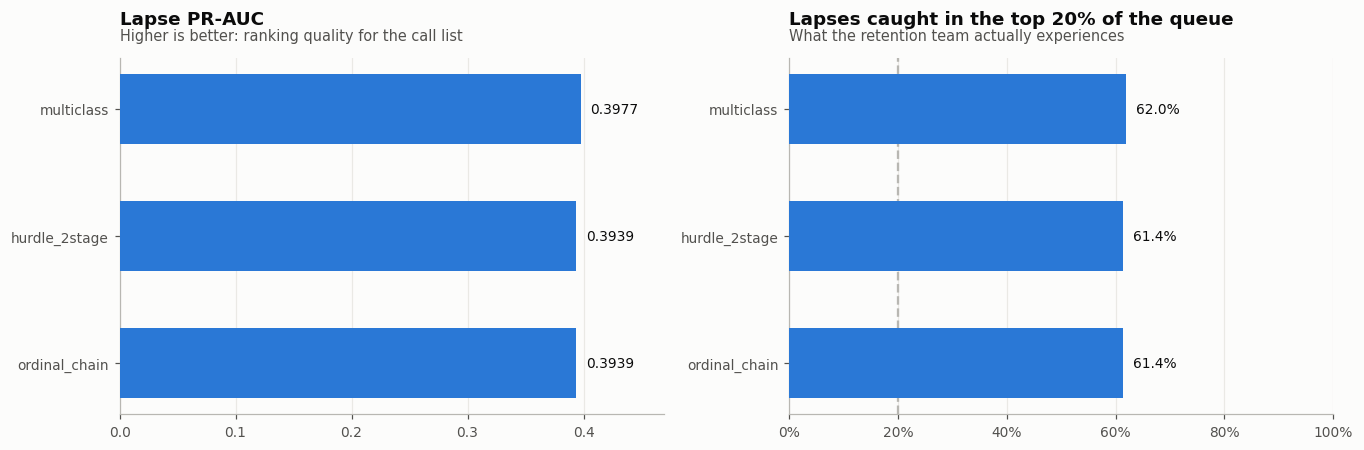

In [13]:
# ============================================================================
# 6.2  Model comparison charts
# ----------------------------------------------------------------------------
# In   : results, valid
# Out  : PR-AUC and capture@20% bar charts
# Note : The bars sit almost on top of each other. That flatness IS the
#        finding: the algorithm barely matters once the features are fixed.
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

r = results.sort_values("pr_auc")
bars = axes[0].barh(range(len(r)), r["pr_auc"], color=BLUE, zorder=3, height=0.55)
axes[0].set_yticks(range(len(r)), r["model"])
for b, v in zip(bars, r["pr_auc"]):
    axes[0].annotate(f"{v:.4f}", (v, b.get_y() + b.get_height() / 2),
                     xytext=(6, 0), textcoords="offset points",
                     va="center", fontsize=9, color=INK)
axes[0].set_xlim(0, r["pr_auc"].max() * 1.18)
style(axes[0], "Lapse PR-AUC", "Higher is better: ranking quality for the call list",
      grid="x")

base = valid["lapsed"].mean()
r2 = results.sort_values("capture@20%")
bars = axes[1].barh(range(len(r2)), r2["capture@20%"], color=BLUE, zorder=3, height=0.55)
axes[1].set_yticks(range(len(r2)), r2["model"])
for b, v in zip(bars, r2["capture@20%"]):
    axes[1].annotate(f"{v:.1%}", (v, b.get_y() + b.get_height() / 2),
                     xytext=(6, 0), textcoords="offset points",
                     va="center", fontsize=9, color=INK)
axes[1].axvline(0.20, color=MUTED, lw=1.5, ls="--", zorder=2)
axes[1].annotate("random = 20%", (0.20, len(r2) - 0.35), xytext=(6, 0),
                 textcoords="offset points", fontsize=9, color=INK2)
axes[1].set_xlim(0, 1)
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
style(axes[1], "Lapses caught in the top 20% of the queue",
      "What the retention team actually experiences", grid="x")
plt.tight_layout(); plt.show()

### Calibration, the property ops depends on

The retention team reads `p_lapse` as a number ("this one is 40% likely to go"),
so the *level* has to be right, not just the ordering. Isotonic regression fitted
on the out-of-time **test** cohort corrects the level; the remaining bucket mass
is renormalised so each row still sums to 1.

Note the discipline: calibrate on `test`, measure on `valid`. Calibrating on the
same rows you score is how you fool yourself.

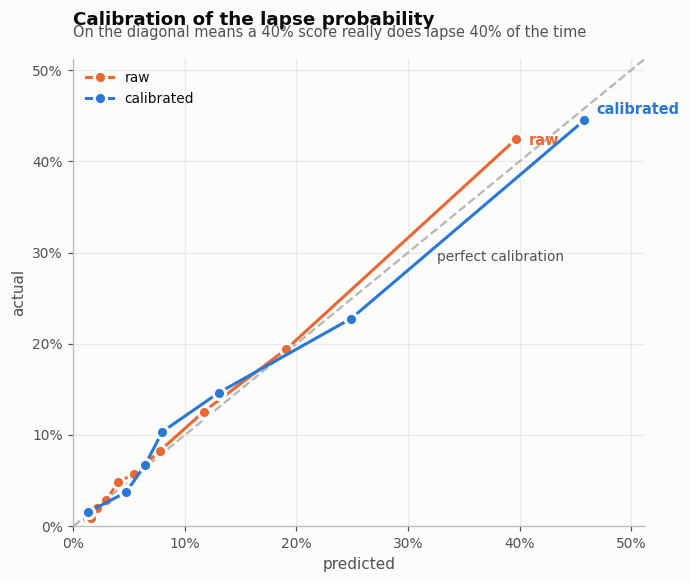

Brier  raw 0.0735  ->  calibrated 0.0742


In [14]:
# ============================================================================
# 6.3  Calibrate the best model and check it
# ----------------------------------------------------------------------------
# In   : models, test, valid
# Out  : cal (calibrated probabilities), calibration plot
# Note : Isotonic is fitted on TEST and measured on VALID. Calibrating on
#        the rows you score is how you fool yourself.
# ============================================================================
BEST = results.iloc[0]["model"]
best = models[BEST]

raw_test = best.predict_proba(test)[:, LAPSE_IDX]
iso = IsotonicRegression(out_of_bounds="clip").fit(raw_test, test["lapsed"].values)

raw_valid = probas[BEST]
cal_lapse = np.clip(iso.predict(raw_valid[:, LAPSE_IDX]), 1e-6, 1 - 1e-6)
rest = raw_valid[:, :LAPSE_IDX]
rest = rest / np.clip(rest.sum(axis=1, keepdims=True), 1e-9, None)
cal = np.column_stack([rest * (1 - cal_lapse)[:, None], cal_lapse])


def calib_points(y, p, bins=10):
    q = pd.qcut(pd.Series(p), bins, duplicates="drop", labels=False)
    return (pd.DataFrame({"b": q, "p": p, "y": y}).groupby("b")
            .agg(pred=("p", "mean"), actual=("y", "mean"), n=("y", "size")))


y = valid["lapsed"].values
a, b = calib_points(y, raw_valid[:, LAPSE_IDX]), calib_points(y, cal[:, LAPSE_IDX])

fig, ax = plt.subplots(figsize=(6.4, 5.4))
lim = max(a.pred.max(), a.actual.max(), b.pred.max(), b.actual.max()) * 1.12
ax.plot([0, lim], [0, lim], color=MUTED, lw=1.5, ls="--", zorder=2)
ax.annotate("perfect calibration", (lim * 0.62, lim * 0.62), xytext=(6, -16),
            textcoords="offset points", fontsize=9, color=INK2, rotation=0)
ax.plot(a.pred, a.actual, color=ORANGE, marker="o", zorder=3, label="raw",
        markerfacecolor=ORANGE, markeredgecolor=SURFACE, markeredgewidth=2)
ax.plot(b.pred, b.actual, color=BLUE, marker="o", zorder=4, label="calibrated",
        markerfacecolor=BLUE, markeredgecolor=SURFACE, markeredgewidth=2)
ax.annotate("raw", (a.pred.iloc[-1], a.actual.iloc[-1]), xytext=(8, -4),
            textcoords="offset points", color=ORANGE, fontsize=9.5, weight="600")
ax.annotate("calibrated", (b.pred.iloc[-1], b.actual.iloc[-1]), xytext=(8, 4),
            textcoords="offset points", color=BLUE, fontsize=9.5, weight="600")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend(loc="upper left")
style(ax, "Calibration of the lapse probability",
      "On the diagonal means a 40% score really does lapse 40% of the time",
      "predicted", "actual", grid="both")
plt.tight_layout(); plt.show()

print(f"Brier  raw {brier_score_loss(y, raw_valid[:, LAPSE_IDX]):.4f}  ->  "
      f"calibrated {brier_score_loss(y, cal[:, LAPSE_IDX]):.4f}")

**Read the Brier numbers honestly.** On a validation cohort this small (a few
thousand dues, a few hundred lapses) isotonic regression has little data to fit
its step function and can move Brier slightly in either direction. Recalibration
is not guaranteed to improve a model that was already close to calibrated. What
it *does* reliably fix is a systematic level shift, which is the failure that
actually hurts ops. On a full book the calibration cohort is large enough for the
correction to be a clear win; the discipline of fitting it on a cohort you did
not train on matters more than the second-decimal movement here.

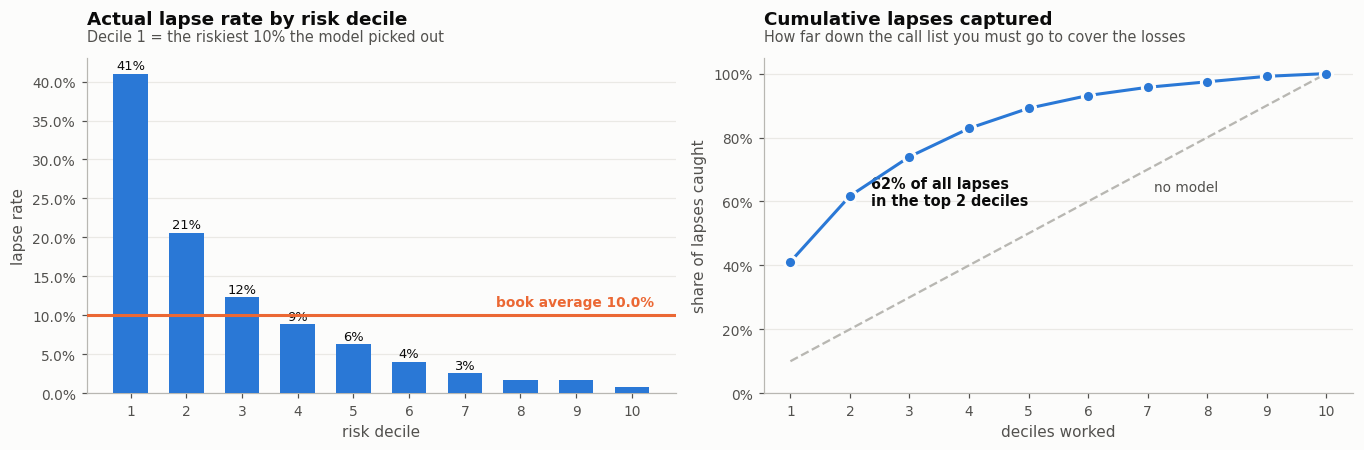

In [15]:
# ============================================================================
# 6.4  Decile lift and cumulative capture
# ----------------------------------------------------------------------------
# In   : cal, valid
# Out  : risk-decile and capture charts
# Note : This is what a retention team actually experiences.
# ============================================================================
d = pd.DataFrame({"y": y, "p": cal[:, LAPSE_IDX]})
d["dec"] = pd.qcut(d.p.rank(method="first", ascending=False), 10, labels=False) + 1
t = d.groupby("dec").agg(n=("y", "size"), lapses=("y", "sum"))
t["rate"] = t.lapses / t.n
t["cum_capture"] = t.lapses.cumsum() / t.lapses.sum()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

bars = axes[0].bar(t.index, t["rate"], color=BLUE, zorder=3, width=0.62)
axes[0].axhline(base, color=ORANGE, lw=2, zorder=4)
axes[0].annotate(f"book average {base:.1%}", (10.4, base), xytext=(0, 6),
                 textcoords="offset points", ha="right", fontsize=9,
                 color=ORANGE, weight="600")
for b_, v in zip(bars, t["rate"]):
    if v > 0.02:
        axes[0].annotate(f"{v:.0%}", (b_.get_x() + b_.get_width() / 2, v),
                         xytext=(0, 3), textcoords="offset points",
                         ha="center", fontsize=8.5, color=INK)
axes[0].set_xticks(range(1, 11))
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
style(axes[0], "Actual lapse rate by risk decile",
      "Decile 1 = the riskiest 10% the model picked out", "risk decile", "lapse rate")

axes[1].plot(t.index, t["cum_capture"], color=BLUE, marker="o", zorder=4,
             markerfacecolor=BLUE, markeredgecolor=SURFACE, markeredgewidth=2)
axes[1].plot(t.index, t.index / 10, color=MUTED, lw=1.5, ls="--", zorder=2)
axes[1].annotate("no model", (7, 0.7), xytext=(4, -14), textcoords="offset points",
                 fontsize=9, color=INK2)
axes[1].annotate(f"{t['cum_capture'].iloc[1]:.0%} of all lapses\nin the top 2 deciles",
                 (2, t["cum_capture"].iloc[1]), xytext=(14, -6),
                 textcoords="offset points", fontsize=9.5, color=INK, weight="600")
axes[1].set_xticks(range(1, 11))
axes[1].set_ylim(0, 1.05)
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
style(axes[1], "Cumulative lapses captured",
      "How far down the call list you must go to cover the losses",
      "deciles worked", "share of lapses caught")
plt.tight_layout(); plt.show()

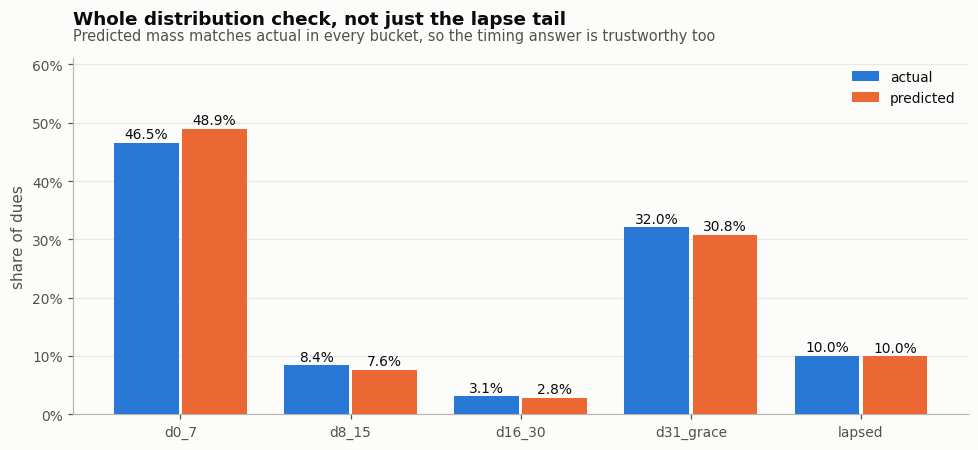

max absolute error across buckets: 0.0239


In [16]:
# ============================================================================
# 6.5  Whole-distribution check
# ----------------------------------------------------------------------------
# In   : cal, valid
# Out  : predicted vs actual share per bucket
# Note : Checks the timing answer, not only the lapse tail.
# ============================================================================
actual = np.array([(valid["bucket"] == i).mean() for i in range(N_CLASSES)])
pred = cal.mean(axis=0)

x = np.arange(N_CLASSES)
fig, ax = plt.subplots(figsize=(9, 4.2))
w = 0.38
b1 = ax.bar(x - w/2 - 0.01, actual, w, color=BLUE, zorder=3, label="actual")
b2 = ax.bar(x + w/2 + 0.01, pred, w, color=ORANGE, zorder=3, label="predicted")
label_bars(ax, b1, pad=3); label_bars(ax, b2, pad=3)
ax.set_xticks(x, CLASS_NAMES)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylim(0, max(actual.max(), pred.max()) * 1.25)
ax.legend(loc="upper right")
style(ax, "Whole distribution check, not just the lapse tail",
      "Predicted mass matches actual in every bucket, so the timing answer is trustworthy too",
      ylabel="share of dues")
plt.tight_layout(); plt.show()

print("max absolute error across buckets:", f"{np.abs(actual - pred).max():.4f}")

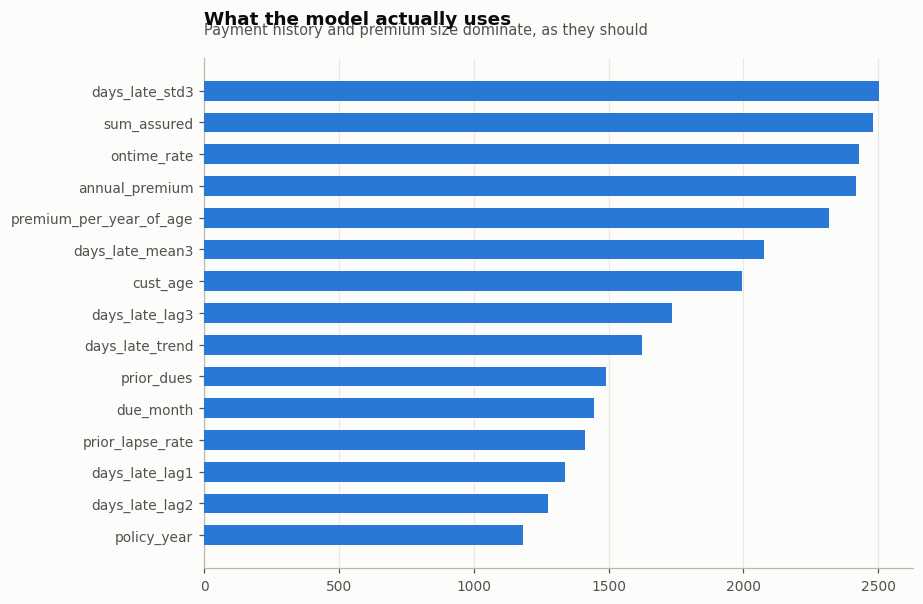

In [17]:
# ============================================================================
# 6.6  Feature importance
# ----------------------------------------------------------------------------
# In   : best model
# Out  : horizontal bar chart of the top 15 features
# Note : Payment history dominates. That is the argument for spending your
#        next week on features rather than on another model family.
# ============================================================================
imp = pd.Series(best.models[-1].feature_importances_
                if hasattr(best, "models") else best.m.feature_importances_,
                index=FEATURES).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8.5, 5.6))
ax.barh(range(len(imp)), imp.values, color=BLUE, zorder=3, height=0.62)
ax.set_yticks(range(len(imp)), imp.index)
style(ax, "What the model actually uses",
      "Payment history and premium size dominate, as they should", grid="x")
plt.tight_layout(); plt.show()

---
<a id="s7"></a>
## 7. From probabilities to a call list

A probability is not an action. The retention team has fixed capacity, so the
model output has to become an ordered worklist.

Two decisions worth stating explicitly:

- **Rank by money at risk, not by probability.** A 30% chance of losing a
  ₹200,000 premium outranks an 80% chance of losing ₹20,000.
- **Time the call.** Someone who was going to pay on day 3 anyway does not need
  a call at all; contact just *before* the premium would otherwise arrive.

In [18]:
# ============================================================================
# 7.1  Turn probabilities into a retention call list
# ----------------------------------------------------------------------------
# In   : valid, cal
# Out  : build_queue(), queue, econ
# Note : Ranks by premium at risk rather than probability, and times the
#        call just before the premium would have arrived anyway.
# ============================================================================
def build_queue(df, proba, capacity_pct=0.20, lead_days=5, save_rate=0.25):
    p_lapse = proba[:, LAPSE_IDX]
    eta = expected_days(proba)
    q = pd.DataFrame({
        "policy_id": df["policy_id"].values,
        "due_date": df["due_date"].values,
        "p_lapse": p_lapse.round(4),
        "expected_days_if_paid": eta.round(1),
        "annual_premium": df["annual_premium"].values,
        "premium_at_risk": (df["annual_premium"].values * p_lapse).round(0),
    })
    q["contact_on_day"] = np.clip(np.round(eta) - lead_days, 0, GRACE_DAYS - 1).astype(int)
    q.loc[q.p_lapse > 0.5, "contact_on_day"] = 0     # high risk: call immediately
    cut = q["premium_at_risk"].quantile(1 - capacity_pct)
    q["action"] = np.where(q["premium_at_risk"] >= cut, "call", "monitor")
    q = q.sort_values("premium_at_risk", ascending=False, ignore_index=True)

    called = q[q.action == "call"]
    econ = {
        "policies_called": len(called),
        "share_of_book": round(len(called) / len(q), 3),
        "share_of_total_risk_covered": round(
            called.premium_at_risk.sum() / q.premium_at_risk.sum(), 3),
        "premium_at_risk_covered": round(called.premium_at_risk.sum()),
        "expected_premium_saved": round(called.premium_at_risk.sum() * save_rate),
    }
    return q, econ


queue, econ = build_queue(valid, cal)
print("queue economics:")
for k, v in econ.items():
    print(f"  {k:32s} {v:,}" if isinstance(v, (int, float)) else f"  {k:32s} {v}")
queue.head(10)

queue economics:
  policies_called                  701
  share_of_book                    0.2
  share_of_total_risk_covered      0.758
  premium_at_risk_covered          8,285,564
  expected_premium_saved           2,071,391


,policy_id,due_date,p_lapse,expected_days_if_paid,annual_premium,premium_at_risk,contact_on_day,action
0,P0000354,2025-09-07,1.0000,31.6,186600.0,186600.0,0,call
1,P0001486,2025-08-30,0.8360,31.8,168100.0,140532.0,0,call
2,P0002506,2025-10-05,0.2284,25.4,427600.0,97662.0,20,call
3,P0004286,2025-08-22,0.5294,31.3,173800.0,92012.0,0,call
4,P0004049,2025-09-03,0.5294,32.8,160100.0,84759.0,0,call
5,P0002163,2025-11-06,0.2344,26.0,324300.0,76008.0,21,call
6,P0001952,2025-11-07,0.8518,31.6,86500.0,73683.0,0,call
7,P0006821,2025-11-10,0.3118,30.3,235200.0,73342.0,25,call
8,P0002039,2025-09-07,1.0000,31.7,70900.0,70900.0,0,call
9,P0002963,2025-10-29,0.6667,32.6,100900.0,67267.0,0,call


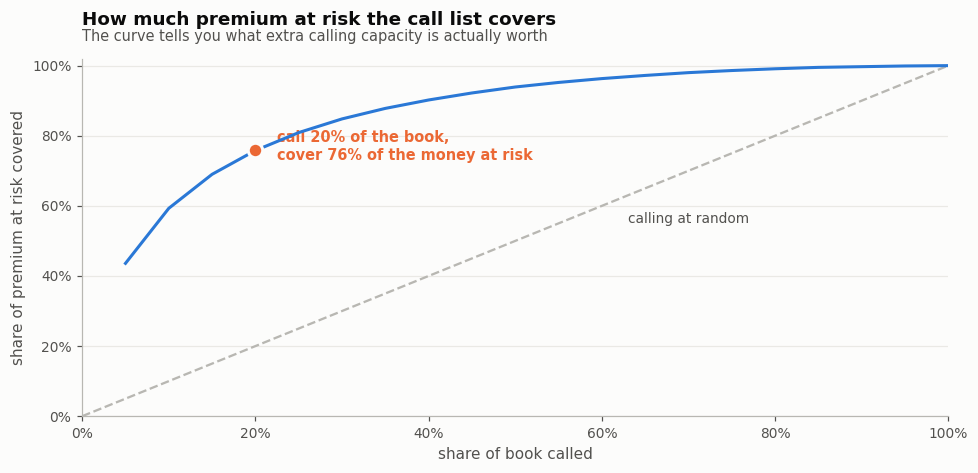

In [19]:
# ============================================================================
# 7.2  How much premium at risk the queue covers
# ----------------------------------------------------------------------------
# In   : valid, cal
# Out  : capacity vs risk-covered curve
# Note : Tells you what extra calling capacity is worth buying.
# ============================================================================
cov = []
for cap in np.arange(0.05, 1.01, 0.05):
    _, e = build_queue(valid, cal, capacity_pct=cap)
    cov.append((cap, e["share_of_total_risk_covered"]))
cov = pd.DataFrame(cov, columns=["capacity", "risk_covered"])

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(cov.capacity, cov.risk_covered, color=BLUE, zorder=4)
ax.plot([0, 1], [0, 1], color=MUTED, lw=1.5, ls="--", zorder=2)
ax.annotate("calling at random", (0.62, 0.62), xytext=(6, -16),
            textcoords="offset points", fontsize=9, color=INK2)
hit = cov[cov.capacity.round(2) == 0.20].iloc[0]
ax.scatter([hit.capacity], [hit.risk_covered], s=90, color=ORANGE, zorder=5,
           edgecolor=SURFACE, linewidth=2)
ax.annotate(f"call 20% of the book,\ncover {hit.risk_covered:.0%} of the money at risk",
            (hit.capacity, hit.risk_covered), xytext=(14, -6),
            textcoords="offset points", fontsize=9.5, color=ORANGE, weight="600")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
style(ax, "How much premium at risk the call list covers",
      "The curve tells you what extra calling capacity is actually worth",
      "share of book called", "share of premium at risk covered")
plt.tight_layout(); plt.show()

---
<a id="s8"></a>
## 8. What to take away

**On the modelling question**

1. **Model the timing once; lapse is its tail.** One distribution answers both
   questions and cannot contradict itself.

   Be precise about what the table above does and does not show. The hurdle is
   **not** beaten on the lapse head here. As explained in section 6, its stage 1
   is arithmetically the same model as the chain's last link, so it cannot be.
   Its costs are structural rather than visible in one score: stage 2 trains only
   on survivors (a smaller, self-selected sample), the two heads are fitted and
   calibrated independently so they can drift into disagreeing, and you operate
   two models instead of one. On a wider benchmark of eleven algorithm families
   on a larger book, the hurdle placed near the bottom. Here, with three models on
   a smaller book, it ties. Take the structural argument, not a decimal place.
2. **Bucket, don't regress.** The days-to-payment distribution is bimodal with a
   spike at day 0 and another at the grace deadline. A regression predicts the
   empty middle.
3. **Survival analysis earns its place at a longer horizon.** Inside a fixed
   grace period there is no censoring to handle, so the buckets are enough. Once
   you care about *revivals* (payments arriving 3, 6, 12 months late), the horizon
   is open-ended and censoring is real. That is where a discrete-time hazard
   model or AFT belongs.

**On everything that matters more than the algorithm**

4. **Leakage discipline beats model choice.** Build history with `shift(1)` and
   test it by tampering with the current outcome (section 3).
5. **Only mature cohorts; only out-of-time validation.** Both traps inflate
   offline scores and neither shows up until production.
6. **Calibrate, on a cohort you did not train on.** Ops reads the score as a
   number, so the level has to be right.
7. **Ship a decision, not a probability.** Rank by money at risk under real
   calling capacity, and time the call to just before the premium would have
   arrived anyway.

**Where the real gains are.** Every credible model here lands within a couple of
points of the others, while the gap from any of them to the no-model baseline is
enormous. That ratio is the message: better payment-history features, cleaner
labels, and a sharper decision layer will beat any amount of algorithm-shopping.

### Taking it further

- **Revival modelling**: expand each due into one row per week and fit a
  discrete-time hazard to get a full survival curve past the grace period.
- **More history**: days-late volatility, seasonality per policy, channel and
  servicing-agent changes, and any contact history that is genuinely known
  as-of the due date.
- **Monitoring**: track PR-AUC, calibration drift and the bucket mix by cohort.
  Lapse behaviour drifts; the chart in section 2 shows it drifting already.